In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/finclub-open-project-26/sandbox_solution.csv
/kaggle/input/competitions/finclub-open-project-26/submission-converter.ipynb
/kaggle/input/competitions/finclub-open-project-26/dataset.csv


# Implied Volatility Surface Reconstruction

## 1. Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import PchipInterpolator, CubicSpline
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## 2. Loading the Dataset

First, I load the competition dataset and check its basic shape. The dataset contains timestamps, underlying price, and implied volatility columns for CE and PE options.

In [3]:
df = pd.read_csv("/kaggle/input/competitions/finclub-open-project-26/dataset.csv")

print("Shape of dataset:",df.shape)
df.head()

Shape of dataset: (975, 30)


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,...,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,...,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


## 3. Basic Data Information

This step helps check data types, missing values, and whether the datetime column needs conversion.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975 entries, 0 to 974
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             975 non-null    object 
 1   underlying_price     975 non-null    float64
 2   NIFTY27JAN2625200CE  781 non-null    float64
 3   NIFTY27JAN2625300CE  791 non-null    float64
 4   NIFTY27JAN2625400CE  773 non-null    float64
 5   NIFTY27JAN2625500CE  794 non-null    float64
 6   NIFTY27JAN2625600CE  795 non-null    float64
 7   NIFTY27JAN2625700CE  774 non-null    float64
 8   NIFTY27JAN2625800CE  765 non-null    float64
 9   NIFTY27JAN2625900CE  793 non-null    float64
 10  NIFTY27JAN2626000CE  794 non-null    float64
 11  NIFTY27JAN2626100CE  792 non-null    float64
 12  NIFTY27JAN2626200CE  766 non-null    float64
 13  NIFTY27JAN2626300CE  788 non-null    float64
 14  NIFTY27JAN2626400CE  762 non-null    float64
 15  NIFTY27JAN2626500CE  791 non-null    flo

In [5]:
df.isna().sum().sort_values(ascending=False)

NIFTY27JAN2624200PE    217
NIFTY27JAN2626400CE    213
NIFTY27JAN2625800CE    210
NIFTY27JAN2624000PE    209
NIFTY27JAN2624800PE    209
NIFTY27JAN2626200CE    209
NIFTY27JAN2625100PE    205
NIFTY27JAN2623800PE    203
NIFTY27JAN2625400CE    202
NIFTY27JAN2624400PE    202
NIFTY27JAN2623900PE    201
NIFTY27JAN2625700CE    201
NIFTY27JAN2624600PE    198
NIFTY27JAN2624900PE    195
NIFTY27JAN2625000PE    195
NIFTY27JAN2624500PE    195
NIFTY27JAN2625200CE    194
NIFTY27JAN2624300PE    189
NIFTY27JAN2626300CE    187
NIFTY27JAN2626500CE    184
NIFTY27JAN2625300CE    184
NIFTY27JAN2626100CE    183
NIFTY27JAN2625900CE    182
NIFTY27JAN2625500CE    181
NIFTY27JAN2626000CE    181
NIFTY27JAN2625600CE    180
NIFTY27JAN2624100PE    176
NIFTY27JAN2624700PE    175
underlying_price         0
datetime                 0
dtype: int64

## 4. Datetime Conversion and Sorting Check

Since this is market time-series data, I converted the datetime column and checked whether the dataset was already sorted.

In [6]:
df["datetime"] = pd.to_datetime(df["datetime"], format="%d-%m-%Y %H:%M")
df = df.sort_values("datetime").reset_index(drop=True)

print("Datetime range:")
print(df["datetime"].min(), "to", df["datetime"].max())

print("\nMonotonic increasing?")
print(df["datetime"].is_monotonic_increasing)

Datetime range:
2026-01-07 09:15:00 to 2026-01-27 15:25:00

Monotonic increasing?
True


## 5. Separating CE and PE Columns

The IV columns are option columns. I separated call options (CE) and put options (PE), and extracted strike prices from the column names.

In [7]:
def get_strike(col):
    return int(col.replace("NIFTY27JAN26", "")[:-2])

strike_cols = [c for c in df.columns if c not in ["datetime", "underlying_price"]]

ce_cols = sorted([c for c in strike_cols if c.endswith("CE")], key=get_strike)
pe_cols = sorted([c for c in strike_cols if c.endswith("PE")], key=get_strike)
iv_cols = ce_cols + pe_cols

ce_strikes = np.array([get_strike(c) for c in ce_cols])
pe_strikes = np.array([get_strike(c) for c in pe_cols])

print("Number of CE columns: ",len(ce_cols))
print("Number of PE columns: ",len(pe_cols))
print("Total IV columns: ",len(iv_cols))

print("\nCE strikes: ",ce_strikes)
print("PE strikes: ",pe_strikes)

Number of CE columns:  14
Number of PE columns:  14
Total IV columns:  28

CE strikes:  [25200 25300 25400 25500 25600 25700 25800 25900 26000 26100 26200 26300
 26400 26500]
PE strikes:  [23800 23900 24000 24100 24200 24300 24400 24500 24600 24700 24800 24900
 25000 25100]


## 6. Missing Value Analysis

The target of the competition is to fill the missing IV values. So I first studied how the missing values are distributed across columns and rows.

In [8]:
missing_count_total = df[iv_cols].isna().sum().sum()
print("Total missing IV values:", missing_count_total)

row_missing = df[iv_cols].isna().sum(axis=1)
print("\nMissing values per row:")
print(row_missing.describe())

col_missing = df[iv_cols].isna().sum().sort_values(ascending=False)
print("\nTop missing columns:")
print(col_missing.head(10))

Total missing IV values: 5460

Missing values per row:
count    975.000000
mean       5.600000
std        2.069134
min        0.000000
25%        4.000000
50%        5.000000
75%        7.000000
max       14.000000
dtype: float64

Top missing columns:
NIFTY27JAN2624200PE    217
NIFTY27JAN2626400CE    213
NIFTY27JAN2625800CE    210
NIFTY27JAN2626200CE    209
NIFTY27JAN2624800PE    209
NIFTY27JAN2624000PE    209
NIFTY27JAN2625100PE    205
NIFTY27JAN2623800PE    203
NIFTY27JAN2625400CE    202
NIFTY27JAN2624400PE    202
dtype: int64


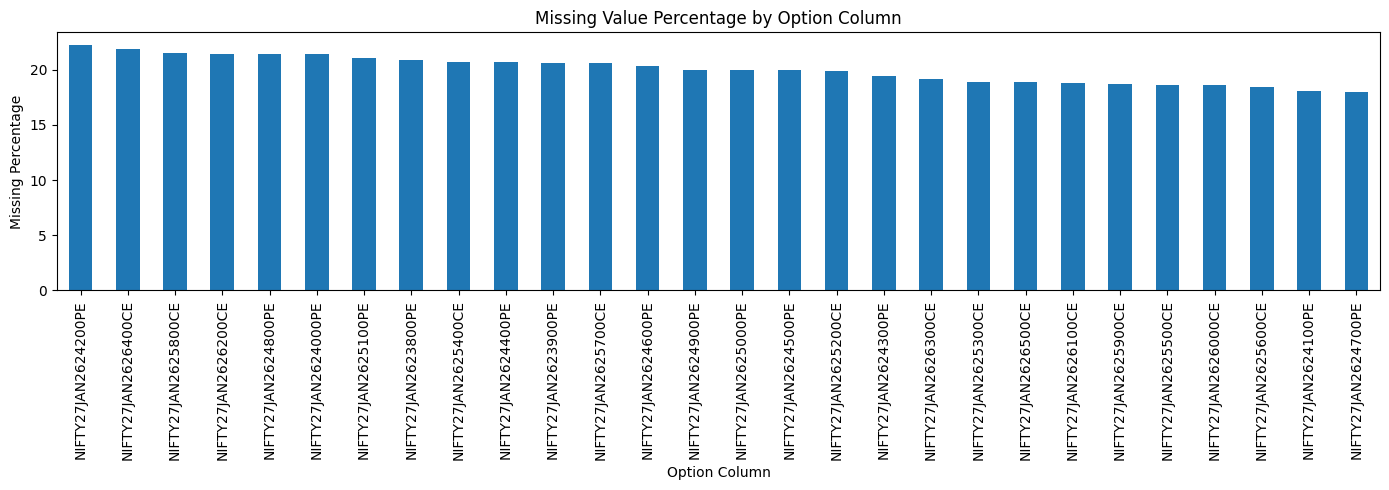

In [9]:
missing_percent = (df[iv_cols].isna().mean()*100).sort_values(ascending=False)

plt.figure(figsize=(14, 5))
missing_percent.plot(kind="bar")
plt.title("Missing Value Percentage by Option Column")
plt.ylabel("Missing Percentage")
plt.xlabel("Option Column")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The missing value percentages are fairly uniform across all option columns, ranging from approximately 18% to 22%. No single strike exhibits significantly higher missingness than the others.

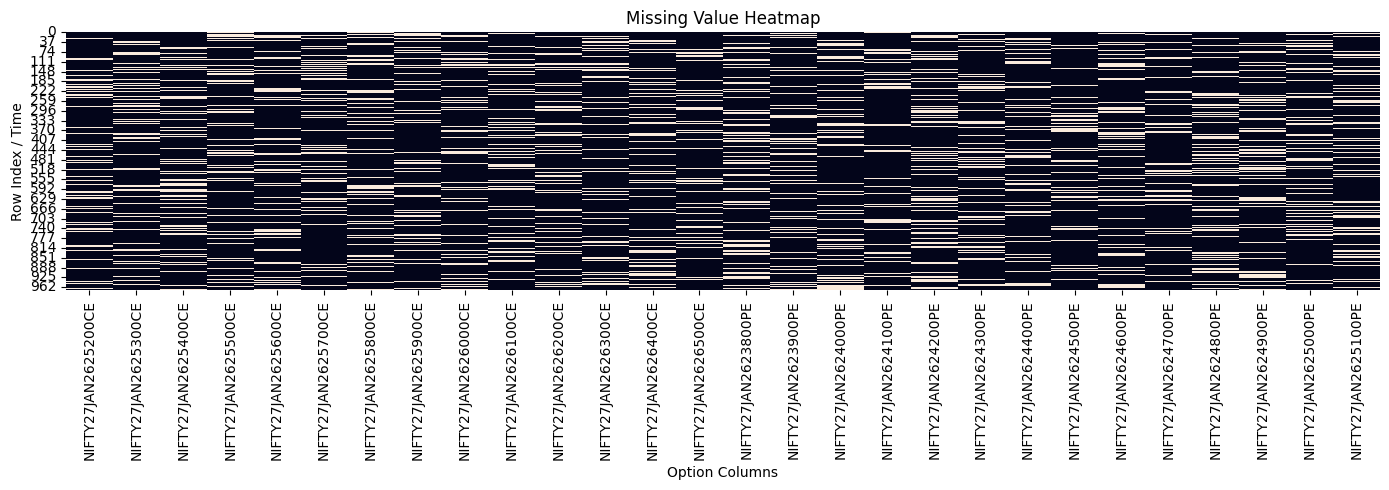

In [10]:
plt.figure(figsize=(14, 5))
sns.heatmap(df[iv_cols].isna(),cbar=False)
plt.title("Missing Value Heatmap")
plt.xlabel("Option Columns")
plt.ylabel("Row Index / Time")
plt.tight_layout()
plt.show()

### Observation

The missing values are scattered across many strikes rather than being limited to one column only. This suggests that cross-sectional interpolation across strikes can be useful.

## 7. Underlying Price Trend

The underlying price is important because option IV is more naturally studied using moneyness instead of raw strike alone.

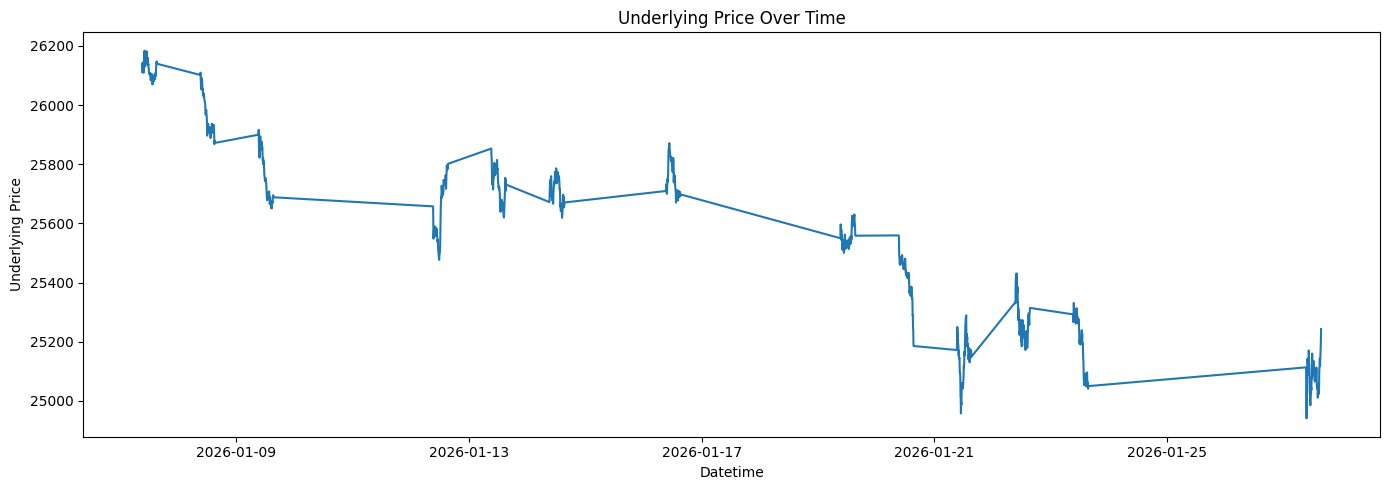

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df["datetime"],df["underlying_price"])
plt.title("Underlying Price Over Time")
plt.xlabel("Datetime")
plt.ylabel("Underlying Price")
plt.tight_layout()
plt.show()

The underlying NIFTY price shows noticeable movement throughout the observation period, declining from around 26,150 to nearly 25,000 before partially recovering towards expiry.

This observation motivates the use of moneyness (strike / underlying price) rather than relying solely on absolute strike values.

## 8. Cross-Sectional IV Curves for CE Options

I plotted CE implied volatility curves for a few timestamps. The x-axis is moneyness, calculated as strike / underlying_price

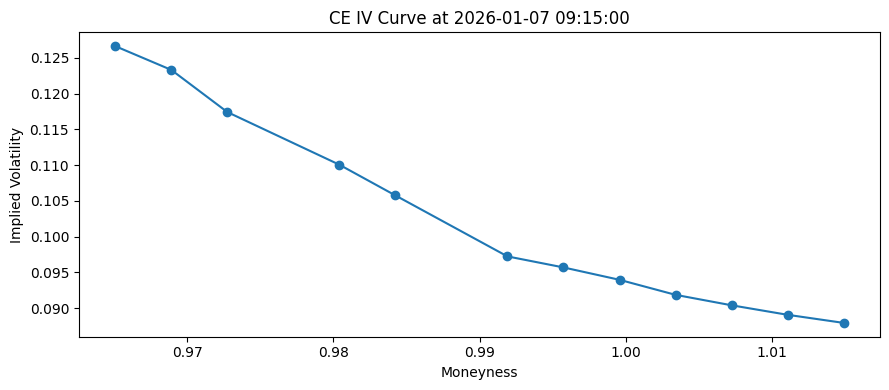

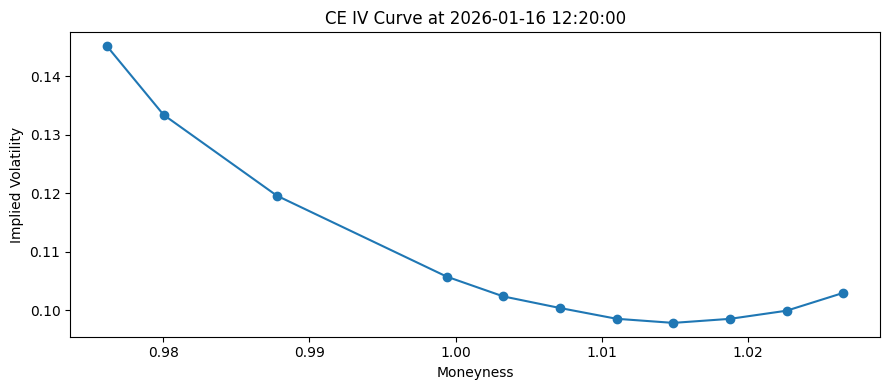

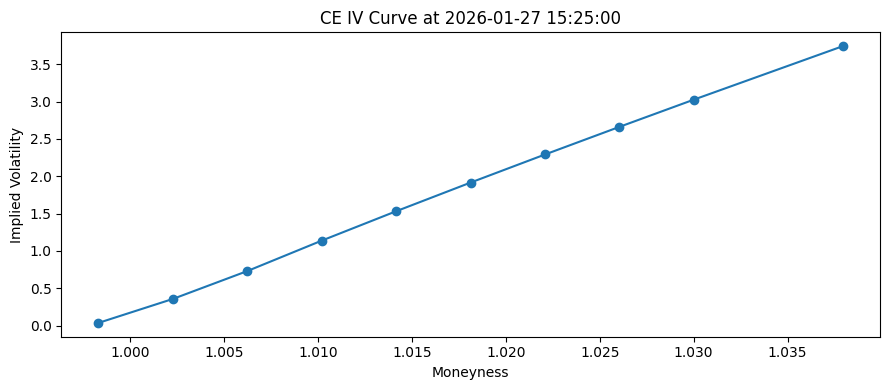

In [12]:
rows_to_plot = [0, len(df)//2, len(df)-1]

for i in rows_to_plot:
    row = df.iloc[i]
    x_vals,y_vals = [],[]

    for col in ce_cols:
        if pd.notna(row[col]):
            strike = get_strike(col)
            x_vals.append(strike/row["underlying_price"])
            y_vals.append(row[col])

    plt.figure(figsize=(9, 4))
    plt.plot(x_vals, y_vals, marker="o")
    plt.xlabel("Moneyness")
    plt.ylabel("Implied Volatility")
    plt.title(f"CE IV Curve at {row['datetime']}")
    plt.tight_layout()
    plt.show()

### Observation

Most CE IV curves are smooth across moneyness levels, making interpolation between neighboring strikes reasonable. However, the final timestamp exhibits a much steeper profile, indicating different behavior near expiry and motivating separate treatment of extreme rows.

## 9. Cross-Sectional IV Curves for PE Options

The same analysis is done for PE options.

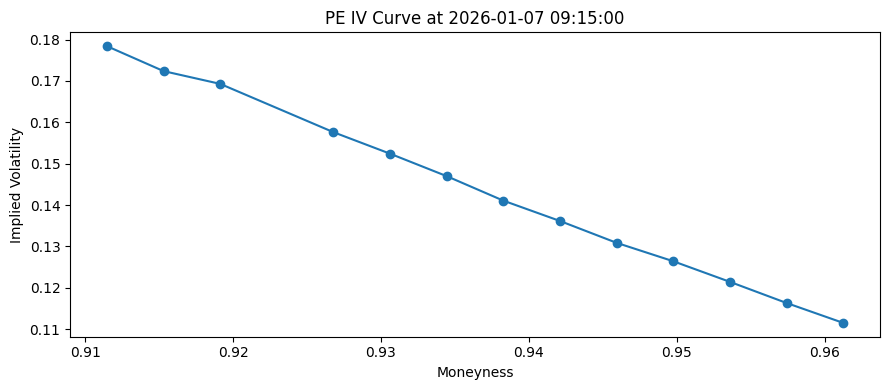

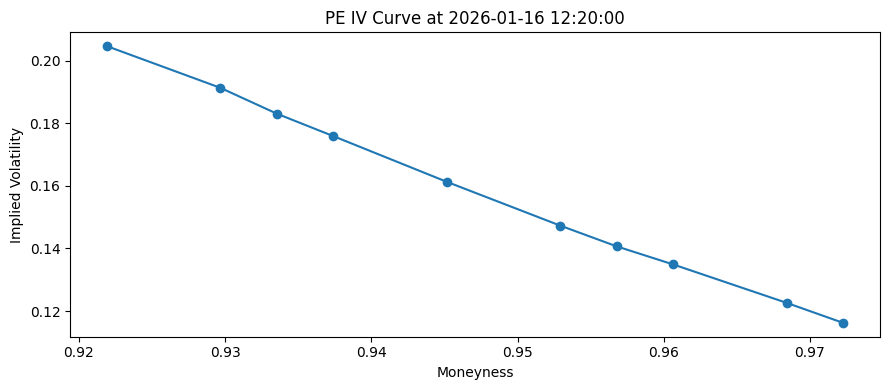

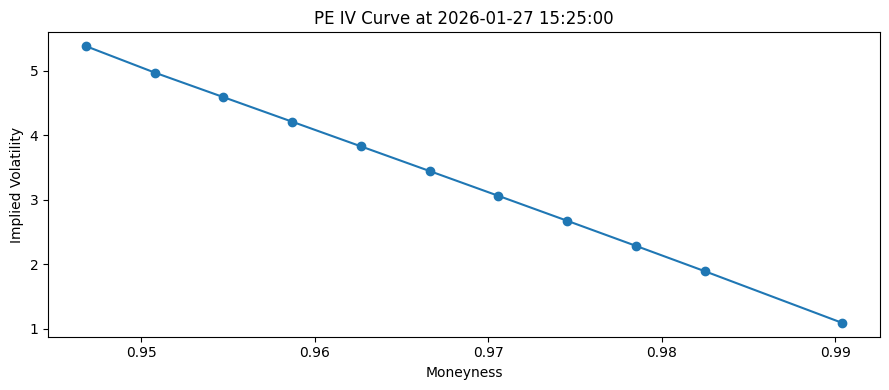

In [13]:
for i in rows_to_plot:
    row = df.iloc[i]
    x_vals, y_vals = [], []

    for col in pe_cols:
        if pd.notna(row[col]):
            strike = get_strike(col)
            x_vals.append(strike / row["underlying_price"])
            y_vals.append(row[col])

    plt.figure(figsize=(9, 4))
    plt.plot(x_vals, y_vals, marker="o")
    plt.xlabel("Moneyness")
    plt.ylabel("Implied Volatility")
    plt.title(f"PE IV Curve at {row['datetime']}")
    plt.tight_layout()
    plt.show()

### Observation

PE IV curves maintain a smooth and consistent shape across time. The final curve displays significantly elevated IV levels, reflecting extreme expiry-period behavior

## 10. Temporal Evolution of Selected CE and PE Strikes

To understand time behavior, I plotted a few representative CE and PE columns over time.

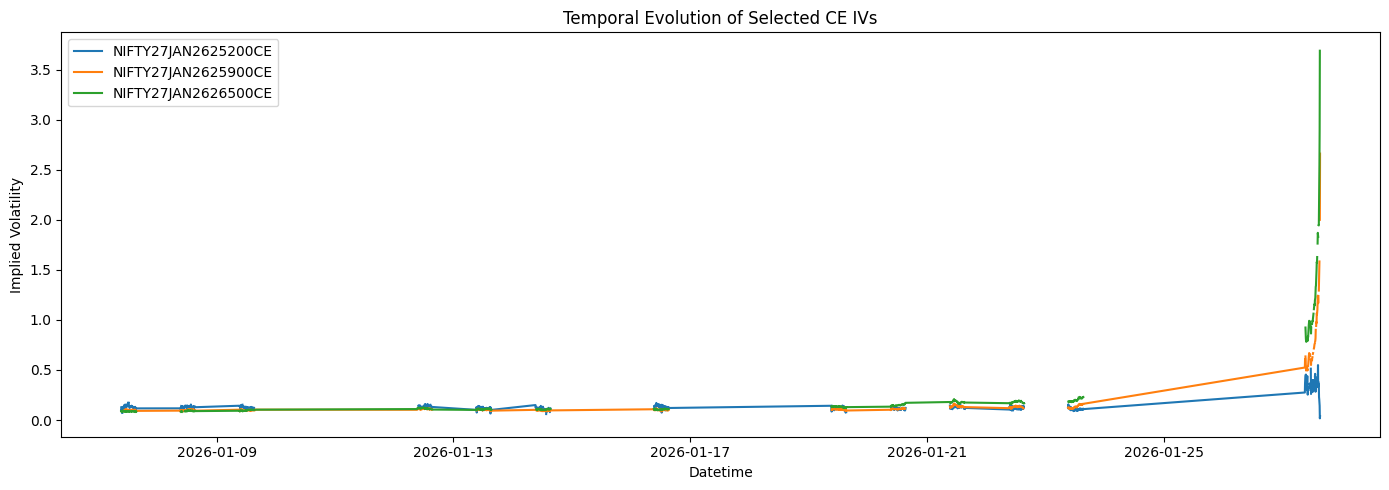

In [14]:
selected_ce = [ce_cols[0], ce_cols[len(ce_cols)//2], ce_cols[-1]]

plt.figure(figsize=(14, 5))
for col in selected_ce:
    plt.plot(df["datetime"], df[col], label=col)

plt.title("Temporal Evolution of Selected CE IVs")
plt.xlabel("Datetime")
plt.ylabel("Implied Volatility")
plt.legend()
plt.tight_layout()
plt.show()

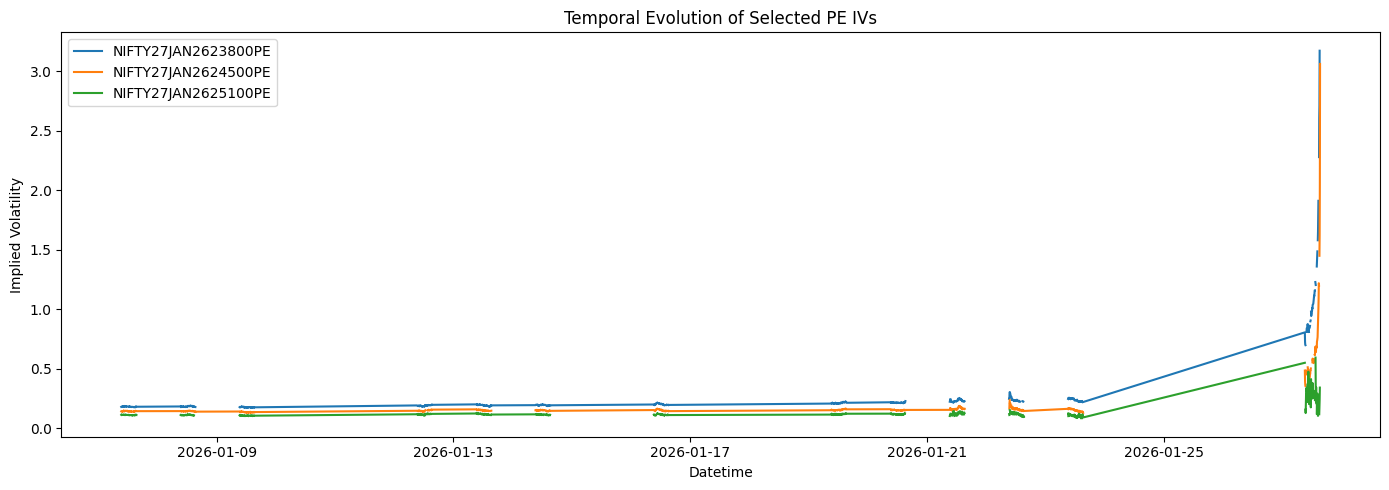

In [15]:
selected_pe = [pe_cols[0], pe_cols[len(pe_cols)//2], pe_cols[-1]]

plt.figure(figsize=(14, 5))
for col in selected_pe:
    plt.plot(df["datetime"], df[col], label=col)

plt.title("Temporal Evolution of Selected PE IVs")
plt.xlabel("Datetime")
plt.ylabel("Implied Volatility")
plt.legend()
plt.tight_layout()
plt.show()

### Observation

The selected CE and PE contracts remain relatively stable for most of the observation period but experience a sharp increase near the final trading sessions. This confirms the presence of extreme expiry-period behavior and supports the need for separate handling of extreme rows during IV reconstruction.

## 11. Long Format Dataset for Understanding

I converted the data to long format for easier feature inspection.

In [16]:
long_rows = []

for idx, row in df.iterrows():
    for col in iv_cols:
        strike = get_strike(col)
        opt_type = "CE" if col.endswith("CE") else "PE"

        long_rows.append({"datetime": row["datetime"],
                          "underlying_price": row["underlying_price"],
                          "option_column": col,
                          "strike": strike,
                          "option_type": opt_type,
                          "moneyness": strike/row["underlying_price"],
                          "log_moneyness": np.log(strike / row["underlying_price"]),
                          "iv": row[col]})

long_df = pd.DataFrame(long_rows)
long_df.head()

,datetime,underlying_price,option_column,strike,option_type,moneyness,log_moneyness,iv
0,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625200CE,25200,CE,0.965086,-0.035538,0.12662
1,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625300CE,25300,CE,0.968916,-0.031577,0.12330
2,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625400CE,25400,CE,0.972746,-0.027632,0.11741
3,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625500CE,25500,CE,0.976576,-0.023703,NaN
4,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625600CE,25600,CE,0.980405,-0.019789,0.11005


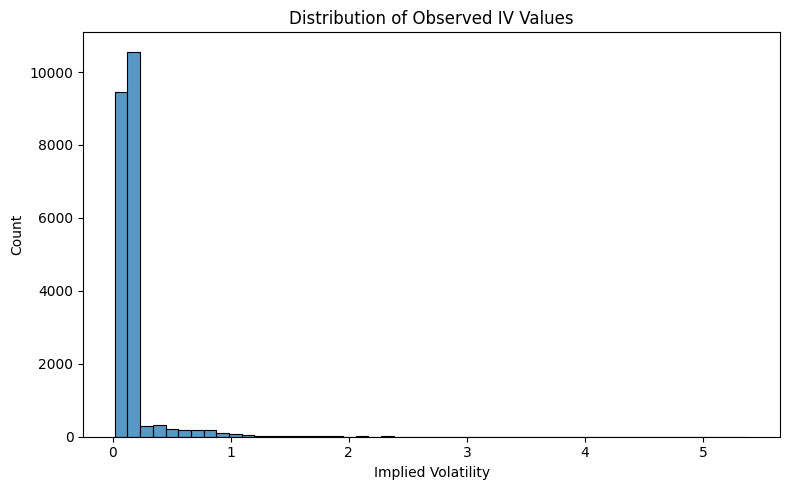

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(long_df["iv"].dropna(), bins=50)
plt.title("Distribution of Observed IV Values")
plt.xlabel("Implied Volatility")
plt.tight_layout()
plt.show()

## 12. Row Range Analysis

One important discovery was that the IV range within a row becomes extremely large near the end of the dataset. I used this as a signal for extreme expiry-like rows.

count    975.000000
mean       0.173556
std        0.332867
min        0.067030
25%        0.089490
50%        0.098670
75%        0.115955
max        5.347500
dtype: float64


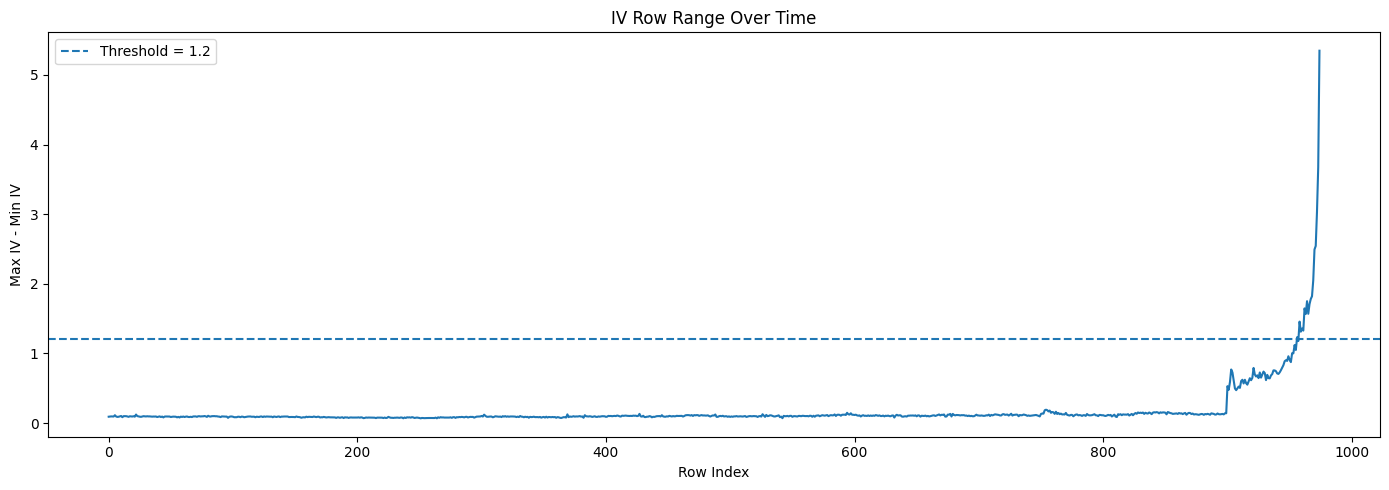


Rows where row range > 1.2:
[956, 958, 959, 960, 961, 962, 963, 964, 965, 966, 967, 968, 969, 970, 971, 972, 973, 974]


In [18]:
row_ranges = []

for i in range(len(df)):
    vals = df.loc[i, iv_cols].dropna().astype(float)
    row_ranges.append(vals.max() - vals.min())

row_ranges = pd.Series(row_ranges, index=df.index)
print(row_ranges.describe())

plt.figure(figsize=(14, 5))
plt.plot(row_ranges.values)
plt.axhline(1.2, linestyle="--", label="Threshold = 1.2")    # Threshold found later
plt.title("IV Row Range Over Time")
plt.xlabel("Row Index")
plt.ylabel("Max IV - Min IV")
plt.legend()
plt.tight_layout()
plt.show()

print("\nRows where row range > 1.2:")
print(df.index[row_ranges > 1.2].tolist())

### Observation

Most rows have very small IV ranges, but the last part of the dataset has very large ranges. These rows behave differently and need special treatment.

## 13. Validation Setup

To compare interpolation methods, I hid 10% of the observed values from each IV column and evaluated reconstruction MSE on those hidden values.

In [19]:
validation_df = df.copy()

true_mask = pd.DataFrame(False,index=df.index,columns=iv_cols)

for col in iv_cols:
    valid_idx = df[df[col].notna()].index
    sampled_idx = pd.Series(valid_idx).sample(frac=0.10, random_state=42)

    validation_df.loc[sampled_idx, col] = np.nan
    true_mask.loc[sampled_idx, col] = True

true_values = df[iv_cols][true_mask]
print("Hidden validation values:", true_mask.sum().sum())

Hidden validation values: 2183


## 14. Baseline Interpolation Functions

I used multiple cross-sectional interpolators. These only use values from the same row, so they avoid lookahead bias.

In [20]:
def strike_pchip(data, cols):
    strikes = np.array([get_strike(c) for c in cols])
    out = data[cols].copy()

    for i in range(len(data)):
        y = data.loc[i, cols].values.astype(float)
        known = ~np.isnan(y)

        if known.sum() >= 2:
            model = PchipInterpolator(strikes[known],y[known],extrapolate=True)
            pred = model(strikes)
            y[~known] = pred[~known]

        out.loc[i,cols] = y
    return out


def strike_cubic(data, cols):
    strikes = np.array([get_strike(c) for c in cols])
    out = data[cols].copy()

    for i in range(len(data)):
        y = data.loc[i, cols].values.astype(float)
        known = ~np.isnan(y)

        if known.sum() >= 2:
            model = CubicSpline(strikes[known],y[known],bc_type="natural",extrapolate=True)
            pred = model(strikes)
            y[~known] = pred[~known]

        out.loc[i, cols] = y
    return out


def strike_quad(data, cols, window=6):
    strikes = np.array([get_strike(c) for c in cols])
    out = data[cols].copy()

    for i in range(len(data)):
        y = data.loc[i, cols].values.astype(float)
        known = ~np.isnan(y)
        filled = y.copy()

        for j in range(len(cols)):
            if np.isnan(y[j]):
                known_idx = np.where(known)[0]

                if len(known_idx) >= 3:
                    nearest = known_idx[np.argsort(np.abs(strikes[known_idx]-strikes[j]))[:window]]
                    deg = min(2, len(nearest) - 1)
                    coef = np.polyfit(strikes[nearest],y[nearest],deg=deg)
                    filled[j] = np.polyval(coef, strikes[j])

        out.loc[i, cols] = filled
    return out


def make_strike_surfaces(data):
    p = data.copy()
    c = data.copy()
    q = data.copy()
    l = data.copy()

    p[ce_cols] = strike_pchip(data,ce_cols)
    p[pe_cols] = strike_pchip(data,pe_cols)

    c[ce_cols] = strike_cubic(data,ce_cols)
    c[pe_cols] = strike_cubic(data,pe_cols)

    q[ce_cols] = strike_quad(data,ce_cols,window=6)
    q[pe_cols] = strike_quad(data,pe_cols,window=6)

    l[ce_cols] = l[ce_cols].interpolate(axis=1, method="linear").ffill(axis=1).bfill(axis=1)
    l[pe_cols] = l[pe_cols].interpolate(axis=1, method="linear").ffill(axis=1).bfill(axis=1)

    for obj in [p,c,q,l]:
        obj[ce_cols] = obj[ce_cols].ffill(axis=1).bfill(axis=1)
        obj[pe_cols] = obj[pe_cols].ffill(axis=1).bfill(axis=1)
        obj[iv_cols] = obj[iv_cols].clip(lower=0.005)

    return p,c,q,l

## 15. Baseline Validation Results

Here I compare simple strike-space methods before moving to the final model.

In [21]:
sp,sc,sq,sl = make_strike_surfaces(validation_df)
baseline_scores = {}

for name, pred_df in {"Linear": sl,"PCHIP": sp,"Cubic": sc,"Quadratic": sq}.items():
    mse = ((df[iv_cols][true_mask]-pred_df[iv_cols][true_mask])**2).stack().mean()
    baseline_scores[name] = mse
    print(name,"MSE: ",mse)

Linear MSE:  0.0010750666714819574
PCHIP MSE:  0.00014089508075819338
Cubic MSE:  0.0001418283400724129
Quadratic MSE:  0.00014694314705138254


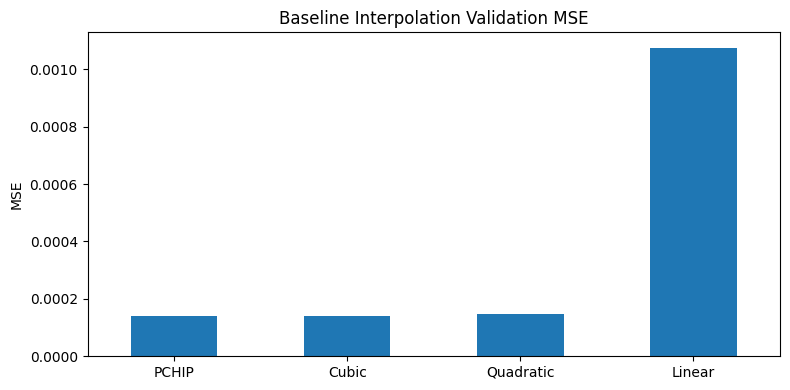

In [22]:
plt.figure(figsize=(8, 4))
pd.Series(baseline_scores).sort_values().plot(kind="bar")
plt.title("Baseline Interpolation Validation MSE")
plt.ylabel("MSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15A. Region-wise Interpolator Check

Before choosing fixed weights, I checked which interpolator works better in different regions of the option surface.  

I divided validation points by:

- CE / PE
- Near / far strikes
- Normal / extreme row-range behavior

In [23]:
region_rows = []

for i in range(len(df)):
    is_extreme = row_ranges.loc[i] > 1.2              # Threshold found later

    for col in iv_cols:
        if not true_mask.loc[i, col]:
            continue

        strike = get_strike(col)
        opt_type = "CE" if col.endswith("CE") else "PE"
        true_val = df.loc[i,col]

        if opt_type == "CE":
            side = "far_CE" if strike >= 26000 else "near_CE"
        else:
            side = "far_PE" if strike <= 24200 else "near_PE"

        region_rows.append({"is_extreme": is_extreme,"side": side,
                            "pchip": (true_val - sp.loc[i, col])**2,
                            "cubic": (true_val - sc.loc[i, col])**2,
                            "quadratic": (true_val - sq.loc[i, col])**2,
                            "linear": (true_val - sl.loc[i, col])**2})

region_df = pd.DataFrame(region_rows)
region_summary = region_df.groupby(["is_extreme", "side"])[["pchip", "cubic", "quadratic", "linear"]].mean()
region_summary["best_method"] = region_summary.idxmin(axis=1)
region_summary

pchip     cubic  quadratic    linear best_method
is_extreme side                                                        
False      far_CE   0.000012  0.000016   0.000039  0.000137       pchip
           far_PE   0.000033  0.000038   0.000013  0.000242   quadratic
           near_CE  0.000027  0.000037   0.000026  0.000056   quadratic
           near_PE  0.000015  0.000035   0.000019  0.000057       pchip
True       far_CE   0.004683  0.002607   0.002874  0.018932       cubic
           far_PE   0.012029  0.012716   0.010402  0.070026   quadratic
           near_CE  0.001466  0.001508   0.001465  0.044402   quadratic
           near_PE  0.001457  0.001515   0.003002  0.010556       pchip

### Observation

The best interpolator was not the same in every region.  
For normal rows, PCHIP and Quadratic were both useful. For extreme rows, Quadratic/Cubic became more important.  
Because of this, I chose weighted blends.

## 15B. Validation for Strike-Space Weights

Here I tested a few simple strike-space blends. The aim was to check whether a small weighted ensemble improves over a single interpolator.

For the strike-space model I used two regimes:

- **Normal rows:** mostly PCHIP with some Cubic and Linear
- **Extreme rows:** more Quadratic influence because the surface is more curved

In [24]:
# Candidate blends for normal and extreme rows
normal_weight_candidates = [("0.70P + 0.30C", 0.70, 0.30, 0.00),
                            ("0.60P + 0.35C + 0.05L", 0.60, 0.35, 0.05),
                            ("0.55P + 0.40C + 0.05L", 0.55, 0.40, 0.05),
                            ("0.50P + 0.45C + 0.05L", 0.50, 0.45, 0.05)]

extreme_weight_candidates = [("0.65Q + 0.30C + 0.05L", 0.65, 0.30, 0.05),
                             ("0.70Q + 0.25C + 0.05L", 0.70, 0.25, 0.05),
                             ("0.75Q + 0.20C + 0.05L", 0.75, 0.20, 0.05),
                             ("0.70Q + 0.30C", 0.70, 0.30, 0.00)]

extreme_rows = row_ranges > 1.2          # Threshold found later
weight_results = []

for n_name, wp, wc, wl in normal_weight_candidates:
    normal_pred = (wp*sp[iv_cols]) + (wc*sc[iv_cols]) + (wl*sl[iv_cols])

    for e_name, wq, wc2, wl2 in extreme_weight_candidates:
        extreme_pred = (wq*sq[iv_cols]) + (wc2*sc[iv_cols]) + (wl2*sl[iv_cols])
        pred = normal_pred.copy()
        pred.loc[extreme_rows, iv_cols] = extreme_pred.loc[extreme_rows, iv_cols]
        mse = ((df[iv_cols][true_mask]-pred[true_mask])**2).stack().mean()
        weight_results.append({"normal_blend": n_name,"extreme_blend": e_name,"validation_mse": mse})

weight_results_df = pd.DataFrame(weight_results).sort_values("validation_mse")
weight_results_df.head(10)

,normal_blend,extreme_blend,validation_mse
4,0.60P + 0.35C + 0.05L,0.65Q + 0.30C + 0.05L,0.000112
8,0.55P + 0.40C + 0.05L,0.65Q + 0.30C + 0.05L,0.000113
0,0.70P + 0.30C,0.65Q + 0.30C + 0.05L,0.000113
12,0.50P + 0.45C + 0.05L,0.65Q + 0.30C + 0.05L,0.000113
5,0.60P + 0.35C + 0.05L,0.70Q + 0.25C + 0.05L,0.000114
9,0.55P + 0.40C + 0.05L,0.70Q + 0.25C + 0.05L,0.000114
1,0.70P + 0.30C,0.70Q + 0.25C + 0.05L,0.000114
13,0.50P + 0.45C + 0.05L,0.70Q + 0.25C + 0.05L,0.000114
6,0.60P + 0.35C + 0.05L,0.75Q + 0.20C + 0.05L,0.000116
10,0.55P + 0.40C + 0.05L,0.75Q + 0.20C + 0.05L,0.000116


### Weight Selection Reasoning

The validation results showed that a blended strike-space model performs better than relying on one interpolator everywhere.

The final strike-space weights used were:

- **Normal rows:** `0.60 PCHIP + 0.35 Cubic + 0.05 Linear`
- **Extreme rows:** `0.70 Quadratic + 0.25 Cubic + 0.05 Linear`

Even when nearby weights were close, this combination was retained because it also performed well on leaderboard checks.

## 15C. Threshold Validation for Extreme Rows

The row-range threshold decides which rows are treated as extreme.  
I tested several thresholds to see where the adaptive strike-space model performs best.

In [25]:
threshold_candidates = [1.0, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4]
threshold_results = []

strike_normal_base = (0.60*sp[iv_cols]) + (0.35*sc[iv_cols]) + (0.05*sl[iv_cols])
strike_extreme_base = (0.70*sq[iv_cols]) + (0.25*sc[iv_cols]) + (0.05*sl[iv_cols])

for threshold in threshold_candidates:
    extreme_mask = row_ranges > threshold
    pred = strike_normal_base.copy()
    pred.loc[extreme_mask, iv_cols] = strike_extreme_base.loc[extreme_mask, iv_cols]
    mse = ((df[iv_cols][true_mask]-pred[true_mask])**2).stack().mean()

    threshold_results.append({"threshold": threshold,
                              "extreme_rows": int(extreme_mask.sum()),
                              "validation_mse": mse})

threshold_results_df = pd.DataFrame(threshold_results).sort_values("validation_mse")
threshold_results_df

,threshold,extreme_rows,validation_mse
1,1.10,20,0.000113
4,1.25,17,0.000114
5,1.30,17,0.000114
0,1.00,23,0.000114
3,1.20,18,0.000114
2,1.15,19,0.000114
6,1.35,15,0.000114
7,1.40,14,0.000116


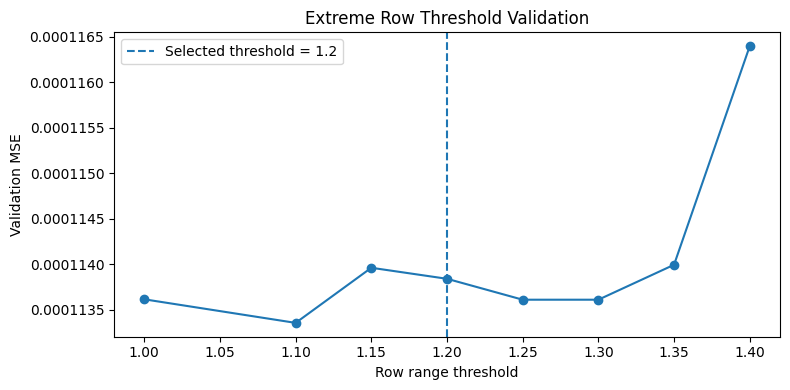

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_results_df.sort_values("threshold")["threshold"],threshold_results_df.sort_values("threshold")["validation_mse"],marker="o")
plt.axvline(1.2, linestyle="--", label="Selected threshold = 1.2")
plt.title("Extreme Row Threshold Validation")
plt.xlabel("Row range threshold")
plt.ylabel("Validation MSE")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold Selection Reasoning

Validation usually placed the best region around 1.2 to 1.3.  
I finally kept **1.2** because it gave the best public leaderboard result in the final submission experiments.  
This was also reasonable because it captures the start of the expiry-like jump rather than only the most extreme rows.

## 16. Strike-Space Model

Based on the validation checks above, I used a two-regime strike-space model.

- **Normal rows:** 0.60 PCHIP + 0.35 Cubic + 0.05 Linear
- **Extreme rows:** 0.70 Quadratic + 0.25 Cubic + 0.05 Linear

The threshold used for extreme rows was: row_range > 1.2

This threshold was shortlisted by validation and then retained because it gave the better public leaderboard result compared with nearby values like 1.25 and 1.30.

In [27]:
extreme_rows = row_ranges > 1.2

strike_normal = (0.60*sp[iv_cols]) + (0.35*sc[iv_cols]) + (0.05*sl[iv_cols])
strike_extreme = (0.70*sq[iv_cols]) + (0.25 * sc[iv_cols])+ (0.05 * sl[iv_cols])

strike_adaptive_val = strike_normal.copy()
strike_adaptive_val.loc[extreme_rows, iv_cols] = strike_extreme.loc[extreme_rows, iv_cols]

strike_adaptive_mse = ((df[iv_cols][true_mask]-strike_adaptive_val[true_mask])**2).stack().mean()
print("Strike adaptive validation MSE:", strike_adaptive_mse)

Strike adaptive validation MSE: 0.00011384059522357428


## 17. Moneyness-Space Cross-Sectional Model

The final improvement came from building another model in log-moneyness space: log(strike / underlying_price)

This model treats middle missing points and edge missing points differently:

- Middle points: PCHIP + local quadratic
- Edge points: weighted polynomial regression + local linear extrapolation
- Expiry rows: pure local linear behavior

This was inspired by the idea that IV smiles are more stable in moneyness space than raw strike space.

In [28]:
spot_vals = df["underlying_price"].values
dates = df["datetime"].dt.date
all_dates = sorted(dates.unique())

def safe_cross_fit(data, min_clip=0.005):
    expiry_dates = set(all_dates[-1:])
    expiry_mask = dates.isin(expiry_dates).values
    filled = data[iv_cols].copy()

    for ti in range(len(data)):
        spot = spot_vals[ti]
        is_expiry = expiry_mask[ti]

        for cols_grp,strikes_arr in [(ce_cols, ce_strikes), (pe_cols, pe_strikes)]:
            row_vals = filled.loc[ti,cols_grp].values.astype(float)
            obs = ~np.isnan(row_vals)
            miss = np.isnan(row_vals)

            if obs.sum()<2 or miss.sum()==0:
                continue

            x_all = np.log(strikes_arr/spot)
            x_obs = x_all[obs]
            y_obs = row_vals[obs]

            sort_i = np.argsort(x_obs)
            x_obs = x_obs[sort_i]
            y_obs = y_obs[sort_i]

            try:
                pchip_model = PchipInterpolator(x_obs,y_obs,extrapolate=True)
                pchip_all = pchip_model(x_all)
            except:
                pchip_all = np.interp(x_all,x_obs,y_obs)

            for mi in np.where(miss)[0]:
                tgt = x_all[mi]
                left_mask = x_obs < tgt
                right_mask = x_obs > tgt
                has_left = left_mask.any()
                has_right = right_mask.any()
                is_middle = has_left and has_right

                # Local linear interpolation / extrapolation
                if has_left and has_right:
                    lx,ly = x_obs[left_mask][-1],y_obs[left_mask][-1]
                    rx,ry = x_obs[right_mask][0],y_obs[right_mask][0]
                    t = (tgt-lx)/(rx-lx+ 1e-12)
                    lin_pred = ly + (t*(ry-ly))

                elif has_left:
                    lx2,ly2 = x_obs[left_mask][-1],y_obs[left_mask][-1]

                    if left_mask.sum() >= 2:
                        lx1,ly1 = x_obs[left_mask][-2],y_obs[left_mask][-2]
                        slope = (ly2 - ly1)/(lx2 - lx1 + 1e-12)
                    else:
                        slope = 0

                    lin_pred = ly2 + (slope*(tgt - lx2))

                else:
                    rx2, ry2 = x_obs[right_mask][0],y_obs[right_mask][0]

                    if right_mask.sum() >= 2:
                        rx1,ry1 = x_obs[right_mask][1],y_obs[right_mask][1]
                        slope = (ry1-ry2)/(rx1-rx2+ 1e-12)
                    else:
                        slope = 0

                    lin_pred = ry2 + (slope*(tgt-rx2))

                # Weighted polynomial regression
                sigma = 0.60*max((x_obs.max()-x_obs.min()) / 2, 0.01)

                weights = np.maximum(np.exp(-0.5*((x_obs - tgt)/sigma)**2),0.05)

                try:
                    deg = min(3, len(x_obs)-1)
                    coef = np.polyfit(x_obs, y_obs, deg=deg, w=weights)
                    poly_pred = float(np.poly1d(coef)(tgt))
                except:
                    poly_pred = lin_pred

                # Local quadratic fit
                try:
                    idxs = np.arange(len(x_obs))
                    nearest = idxs[np.argsort(np.abs(x_obs - tgt))[:6]]
                    deg2 = min(2,len(nearest)-1)
                    coef2 = np.polyfit(x_obs[nearest],y_obs[nearest],deg=deg2)
                    quad_pred = float(np.poly1d(coef2)(tgt))

                except:
                    quad_pred = poly_pred

                pchip_pred = float(pchip_all[mi])

                if is_expiry:
                    pred = lin_pred
                else:
                    if is_middle:
                        pred = (0.40*pchip_pred) + (0.60*quad_pred)
                    else:
                        pred = (0.70*poly_pred) + (0.30*lin_pred)

                filled.loc[ti, cols_grp[mi]] = max(pred, min_clip)

    filled = filled.ffill(axis=1).bfill(axis=1)
    filled = filled.clip(lower=min_clip)
    return filled

## 18. Moneyness Model Validation

In [29]:
money_val = safe_cross_fit(validation_df)
money_mse = ((df[iv_cols][true_mask]-money_val[iv_cols][true_mask])**2).stack().mean()

print("Moneyness model validation MSE:", money_mse)

Moneyness model validation MSE: 0.0001100174127929323


## 18A. Validation for Moneyness vs Strike Blend

After building both models, I tested how much weight should be given to the moneyness-space model and how much should remain with the strike-space adaptive model.

This validation is important because using only one view was not enough:

- Pure strike-space model captures local strike shape.
- Pure moneyness-space model adjusts better for underlying price movement.
- The blend combines both.

In [30]:
blend_weights = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.7, 0.8, 0.9, 1.0]
blend_results = []

for w_money in blend_weights:
    pred = (w_money * money_val[iv_cols]) + ((1 - w_money)*strike_adaptive_val[iv_cols])
    mse = ((df[iv_cols][true_mask]-pred[true_mask])**2).stack().mean()
    blend_results.append({"w_money": w_money,"w_strike": 1-w_money,"validation_mse": mse})

blend_results_df = pd.DataFrame(blend_results).sort_values("validation_mse")
blend_results_df

,w_money,w_strike,validation_mse
6,0.55,0.45,0.000102
7,0.60,0.40,0.000102
5,0.50,0.50,0.000103
8,0.70,0.30,0.000103
4,0.40,0.60,0.000103
9,0.80,0.20,0.000105
3,0.30,0.70,0.000105
10,0.90,0.10,0.000107
2,0.20,0.80,0.000107
11,1.00,0.00,0.000110


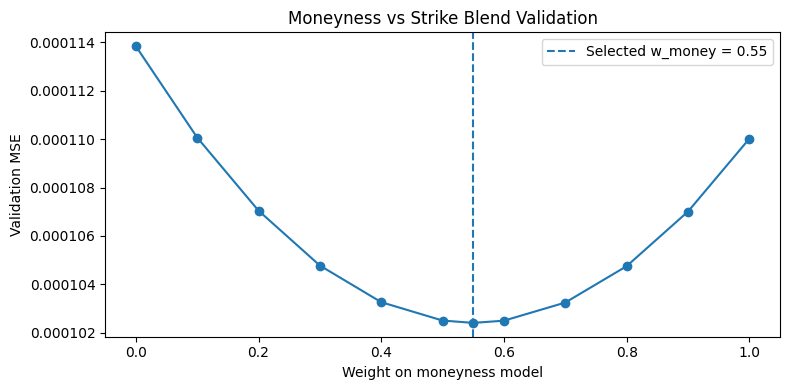

In [31]:
plt.figure(figsize=(8, 4))
plot_df = pd.DataFrame(blend_results).sort_values("w_money")
plt.plot(plot_df["w_money"], plot_df["validation_mse"], marker="o")
plt.axvline(0.55, linestyle="--", label="Selected w_money = 0.55")
plt.title("Moneyness vs Strike Blend Validation")
plt.xlabel("Weight on moneyness model")
plt.ylabel("Validation MSE")
plt.legend()
plt.tight_layout()
plt.show()

### Blend Selection Reasoning

The validation curve showed that the best region was around 0.5 to 0.6 weight on the moneyness model.  


I selected: (0.55* Moneyness Model) + (0.45* Strike Adaptive Model)

because it was in the best validation region and gave the best leaderboard score among nearby tested weights.

## 19. Final Blend Validation

The validation above suggested that the final prediction should combine the moneyness-space model and the strike-space adaptive model.

The selected blend was:  Final = (0.55* Moneyness Model) + (0.45* Strike Adaptive Model)

This weight was chosen because validation consistently preferred the 0.5–0.6 moneyness-weight region, and 0.55/0.45 gave the best leaderboard result among the nearby tested blends.

In [32]:
final_val_pred = (0.55*money_val[iv_cols]) + (0.45*strike_adaptive_val[iv_cols])
final_val_mse = ((df[iv_cols][true_mask]-final_val_pred[true_mask])**2).stack().mean()

print("Final blended validation MSE:", final_val_mse)

Final blended validation MSE: 0.00010240764558573592


### Validation Summary

The final blend performed better than using only the strike model or only the moneyness model. This shows that both views capture useful information:

- Strike-space captures local strike structure.
- Moneyness-space adjusts for underlying price movement.
- Edge treatment helps with extrapolation cases.

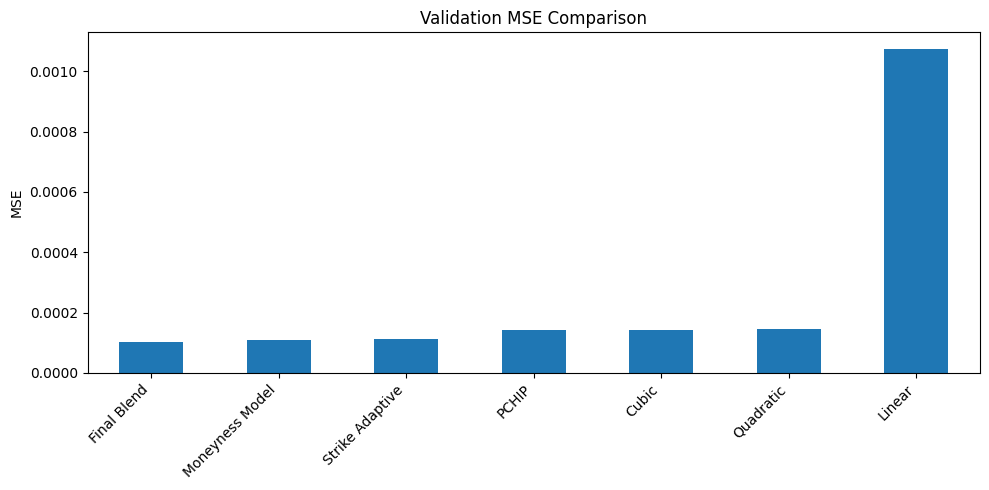

Final Blend        0.000102
Moneyness Model    0.000110
Strike Adaptive    0.000114
PCHIP              0.000141
Cubic              0.000142
Quadratic          0.000147
Linear             0.001075
dtype: float64

In [33]:
summary_scores = pd.Series({"Linear": baseline_scores["Linear"],
                            "PCHIP": baseline_scores["PCHIP"],
                            "Cubic": baseline_scores["Cubic"],
                            "Quadratic": baseline_scores["Quadratic"],
                            "Strike Adaptive": strike_adaptive_mse,
                            "Moneyness Model": money_mse,
                            "Final Blend": final_val_mse}).sort_values()

plt.figure(figsize=(10, 5))
summary_scores.plot(kind="bar")
plt.title("Validation MSE Comparison")
plt.ylabel("MSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

summary_scores

## 20. Final Model on Full Dataset

Now I train/apply the final method on the original dataset and generate the final submission file.

In [34]:
# Recreate final moneyness prediction on full data
money_pred = safe_cross_fit(df)

# Recreate strike adaptive prediction on full data
sp_full, sc_full, sq_full, sl_full = make_strike_surfaces(df)

strike_normal_full = (0.60 * sp_full[iv_cols]) + (0.35 * sc_full[iv_cols]) + (0.05 * sl_full[iv_cols])
strike_extreme_full = (0.70 * sq_full[iv_cols]) + (0.25 * sc_full[iv_cols]) + (0.05 * sl_full[iv_cols])

strike_adaptive_full = strike_normal_full.copy()
strike_adaptive_full.loc[extreme_rows, iv_cols] = strike_extreme_full.loc[extreme_rows,iv_cols]

# Final best blend
final_pred = (0.55*money_pred[iv_cols]) + (0.45*strike_adaptive_full[iv_cols])
final_pred = final_pred.clip(lower=0.005)

print("Final missing values:", final_pred.isna().sum().sum())
print("Final IV range:", final_pred.min().min(), "to", final_pred.max().max())

Final missing values: 0
Final IV range: 0.013750269221500654 to 5.781733575772515


## 21. Submission File Creation

The final submission contains only the originally missing values, arranged in the same order as the sample solution.

In [35]:
original = pd.read_csv("/kaggle/input/competitions/finclub-open-project-26/dataset.csv")
rows = []

for col in iv_cols:
    for idx in original.index[original[col].isna()]:
        rows.append({"id": f"{original.loc[idx, 'datetime']}||{col}","value": final_pred.loc[idx, col]})

submission = pd.DataFrame(rows, columns=["id", "value"])
sample = pd.read_csv("/kaggle/input/competitions/finclub-open-project-26/sandbox_solution.csv")
submission = submission.set_index("id").loc[sample["id"]].reset_index()
submission.to_csv("submission.csv", index=False)

print("Submission shape:", submission.shape)
print(submission.head())
print("\nNaN check:")
print(submission.isna().sum())

Submission shape: (5460, 2)
                                      id     value
0  07-01-2026 09:15||NIFTY27JAN2624100PE  0.163638
1  07-01-2026 09:15||NIFTY27JAN2625500CE  0.113676
2  07-01-2026 09:15||NIFTY27JAN2625800CE  0.101095
3  07-01-2026 09:20||NIFTY27JAN2624000PE  0.170104
4  07-01-2026 09:20||NIFTY27JAN2624200PE  0.159774

NaN check:
id       0
value    0
dtype: int64


## 22. Final Notes

The important learning from this project was that simple interpolation was not enough. The IV surface behaved normally in most rows, but expiry-like rows showed a very different pattern.

My final approach therefore used:

1. **Moneyness-space interpolation** for better surface alignment.
2. **PCHIP and quadratic fitting in the middle** of the strike range.
3. **Regression/linear behavior near edges**.
4. **A separate strike-space adaptive model** for extreme rows.
5. **A final 55/45 blend** between moneyness-space and strike-space predictions.